In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import sys
from datetime import datetime
import math
import warnings
warnings.filterwarnings("ignore")



In [56]:
# Load data
data = pd.read_csv('Social Media & User Behavior — Global 2026/social_media_user_behavior.csv')
# Display first few rows of the dataset
data.head()


,user_id,age,age_group,gender,country,occupation,education_level,income_bracket,relationship_status,primary_platform,...,productivity_impact,platform_satisfaction,account_created_date,account_age_years,is_verified_account,is_content_creator,uses_ai_features,daily_notifications,checks_phone_first_morning,uses_screen_time_limits
0,USR-000001,22,18-24,Non-Binary,Philippines,Teacher/Educator,Doctoral/Professional,$100K-$150K,Married,Facebook,...,No Change,Dissatisfied,14/05/2025,0.9,False,False,False,20,True,False
1,USR-000002,31,25-34,Prefer Not to Say,United Kingdom,Marketing Professional,High School or Below,$50K-$75K,In a Relationship,TikTok,...,No Change,Dissatisfied,18/07/2019,6.7,False,False,False,31,True,False
2,USR-000003,21,18-24,Female,UAE,Legal Professional,High School or Below,$25K-$50K,Single,Instagram,...,Decreased,Neutral,10/01/2026,0.2,False,False,False,47,True,False
3,USR-000004,33,25-34,Female,Saudi Arabia,Unemployed,Some College,$25K-$50K,Single,Instagram,...,Decreased,Neutral,28/09/2019,6.5,False,False,False,28,True,False
4,USR-000005,23,18-24,Female,Poland,Sales Professional,Vocational/Trade,$25K-$50K,It's Complicated,Reddit,...,Increased,Neutral,05/04/2022,4.0,False,True,False,149,True,False


In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   user_id                             25000 non-null  object 
 1   age                                 25000 non-null  int64  
 2   age_group                           25000 non-null  object 
 3   gender                              25000 non-null  object 
 4   country                             25000 non-null  object 
 5   occupation                          25000 non-null  object 
 6   education_level                     25000 non-null  object 
 7   income_bracket                      25000 non-null  object 
 8   relationship_status                 25000 non-null  object 
 9   primary_platform                    25000 non-null  object 
 10  num_platforms_used                  25000 non-null  int64  
 11  daily_screen_time_minutes           25000

In [58]:
data["account_created_date"] = pd.to_datetime(
    data["account_created_date"],
    errors="coerce"
)

C:\Users\HOss\AppData\Local\Temp\ipykernel_21284\3644923217.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  data["account_created_date"] = pd.to_datetime(


In [59]:
# Separate Column Types
# =========================
print("\nNumerical summary:")
display(data.describe())


Numerical summary:


,age,num_platforms_used,daily_screen_time_minutes,weekly_sessions,avg_session_duration_minutes,posts_per_week,likes_per_day,comments_per_day,shares_per_week,followers_count,following_count,engagement_rate_pct,video_consumption_daily_minutes,monthly_social_spending_usd,sleep_hours_per_night,addiction_level_1_to_10,account_created_date,account_age_years,daily_notifications
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000,25000.000000,25000.000000
mean,34.683840,4.857760,141.122480,9.008760,98.106852,3.008480,11.540120,2.467080,3.52844,1700.168840,444.304800,1.869696,77.435320,11.886130,7.026960,2.889920,2018-02-05 08:02:17.088000,8.149920,44.558280
min,13.000000,1.000000,5.000000,1.000000,5.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,1.000000,2010-01-01 00:00:00,0.000000,0.000000
25%,23.000000,4.000000,95.000000,5.000000,78.400000,1.000000,3.000000,0.000000,1.00000,64.000000,54.000000,1.220000,49.000000,3.400000,6.400000,1.000000,2014-01-05 00:00:00,4.100000,13.000000
50%,31.000000,5.000000,137.000000,9.000000,97.250000,2.000000,8.000000,2.000000,2.00000,244.000000,147.000000,1.840000,76.000000,8.300000,7.000000,3.000000,2018-02-01 12:00:00,8.200000,31.000000
75%,44.000000,6.000000,182.000000,12.000000,117.100000,4.000000,16.000000,4.000000,5.00000,942.000000,401.000000,2.500000,103.000000,16.450000,7.700000,4.000000,2022-02-08 00:00:00,12.200000,62.000000
max,85.000000,12.000000,467.000000,31.000000,272.100000,33.000000,117.000000,29.000000,46.00000,525545.000000,46261.000000,6.580000,261.000000,120.680000,11.000000,10.000000,2026-03-31 00:00:00,16.200000,486.000000
std,15.150185,1.965279,62.577221,4.946949,32.057524,3.469272,12.102995,2.899375,4.01998,8671.294106,1155.077278,1.029810,39.224055,11.891551,0.940823,1.698728,NaN,4.681402,45.216086


In [60]:
# Value Counts for Categorical Columns
print("\nCategorical summary:")
display(data.describe(include="object"))


Categorical summary:


,user_id,age_group,gender,country,occupation,education_level,income_bracket,relationship_status,primary_platform,preferred_content_type,primary_device,usage_purpose,ad_click_frequency,reports_fake_news_frequency,self_reported_mental_health_effect,productivity_impact,platform_satisfaction
count,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000,25000
unique,25000,7,4,35,20,6,7,6,15,12,5,10,4,4,5,3,5
top,USR-025000,25-34,Female,India,Unemployed,Bachelor's Degree,$25K-$50K,Single,Instagram,Short-Form Video,Smartphone,News & Information,Rarely,Never,Neutral,No Change,Satisfied
freq,1,7091,11930,3598,1348,7527,6145,8798,4434,5575,15573,2581,10026,9990,12262,10513,7503


In [61]:
# show duplicate rows
duplicates = data.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [62]:
# Separate Column Types
# =========================
numerical_cols = data.select_dtypes(include=np.number).columns
categorical_cols = data.select_dtypes(include=["object", "category"]).columns
datetime_cols = data.select_dtypes(include=["datetime64[ns]"]).columns

print("\nNumerical columns:", list(numerical_cols))
print("Categorical columns:", list(categorical_cols))
print("Datetime columns:", list(datetime_cols))


Numerical columns: ['age', 'num_platforms_used', 'daily_screen_time_minutes', 'weekly_sessions', 'avg_session_duration_minutes', 'posts_per_week', 'likes_per_day', 'comments_per_day', 'shares_per_week', 'followers_count', 'following_count', 'engagement_rate_pct', 'video_consumption_daily_minutes', 'monthly_social_spending_usd', 'sleep_hours_per_night', 'addiction_level_1_to_10', 'account_age_years', 'daily_notifications']
Categorical columns: ['user_id', 'age_group', 'gender', 'country', 'occupation', 'education_level', 'income_bracket', 'relationship_status', 'primary_platform', 'preferred_content_type', 'primary_device', 'usage_purpose', 'ad_click_frequency', 'reports_fake_news_frequency', 'self_reported_mental_health_effect', 'productivity_impact', 'platform_satisfaction']
Datetime columns: ['account_created_date']


user_id                               25000
country                                  35
occupation                               20
primary_platform                         15
preferred_content_type                   12
usage_purpose                            10
age_group                                 7
income_bracket                            7
education_level                           6
relationship_status                       6
platform_satisfaction                     5
primary_device                            5
self_reported_mental_health_effect        5
gender                                    4
ad_click_frequency                        4
reports_fake_news_frequency               4
productivity_impact                       3
dtype: int64

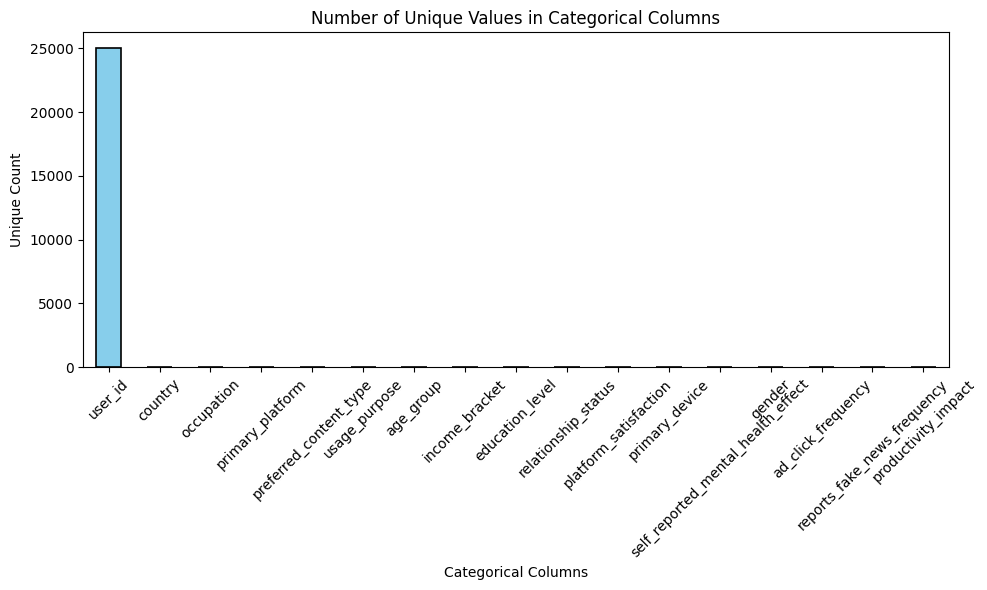

In [63]:
# Unique Values in Categorical Columns
# =========================
if len(categorical_cols) > 0:
    unique_counts = data[categorical_cols].nunique().sort_values(ascending=False)
    display(unique_counts)

    unique_counts.plot(kind="bar", color="skyblue", figsize=(10, 6), edgecolor="black", linewidth=1.2)
    plt.title("Number of Unique Values in Categorical Columns")
    plt.ylabel("Unique Count")
    plt.xlabel("Categorical Columns")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [64]:
# Compact summary of top categorical values
top_n = 5

categorical_summary = pd.DataFrame({
    "unique_count": data[categorical_cols].nunique(),
    "most_frequent": data[categorical_cols].mode().iloc[0],
    "most_frequent_count": data[categorical_cols].apply(lambda col: col.value_counts(dropna=False).iloc[0])
})

display(categorical_summary.sort_values(by="unique_count", ascending=False))


,unique_count,most_frequent,most_frequent_count
user_id,25000,USR-000001,1
country,35,India,3598
occupation,20,Unemployed,1348
primary_platform,15,Instagram,4434
preferred_content_type,12,Short-Form Video,5575
usage_purpose,10,News & Information,2581
age_group,7,25-34,7091
income_bracket,7,$25K-$50K,6145
education_level,6,Bachelor's Degree,7527
relationship_status,6,Single,8798


# Visualse

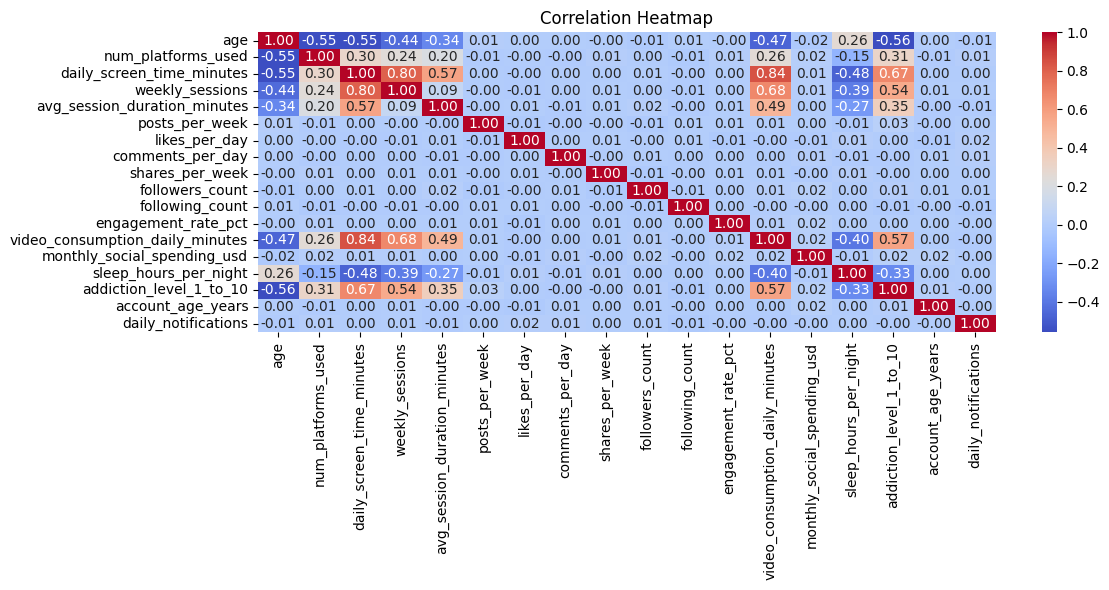

In [86]:
# Correlation matrix
if len(numerical_cols) > 1:
    corr_matrix = data[numerical_cols].corr()

    plt.figure(figsize=(12, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()



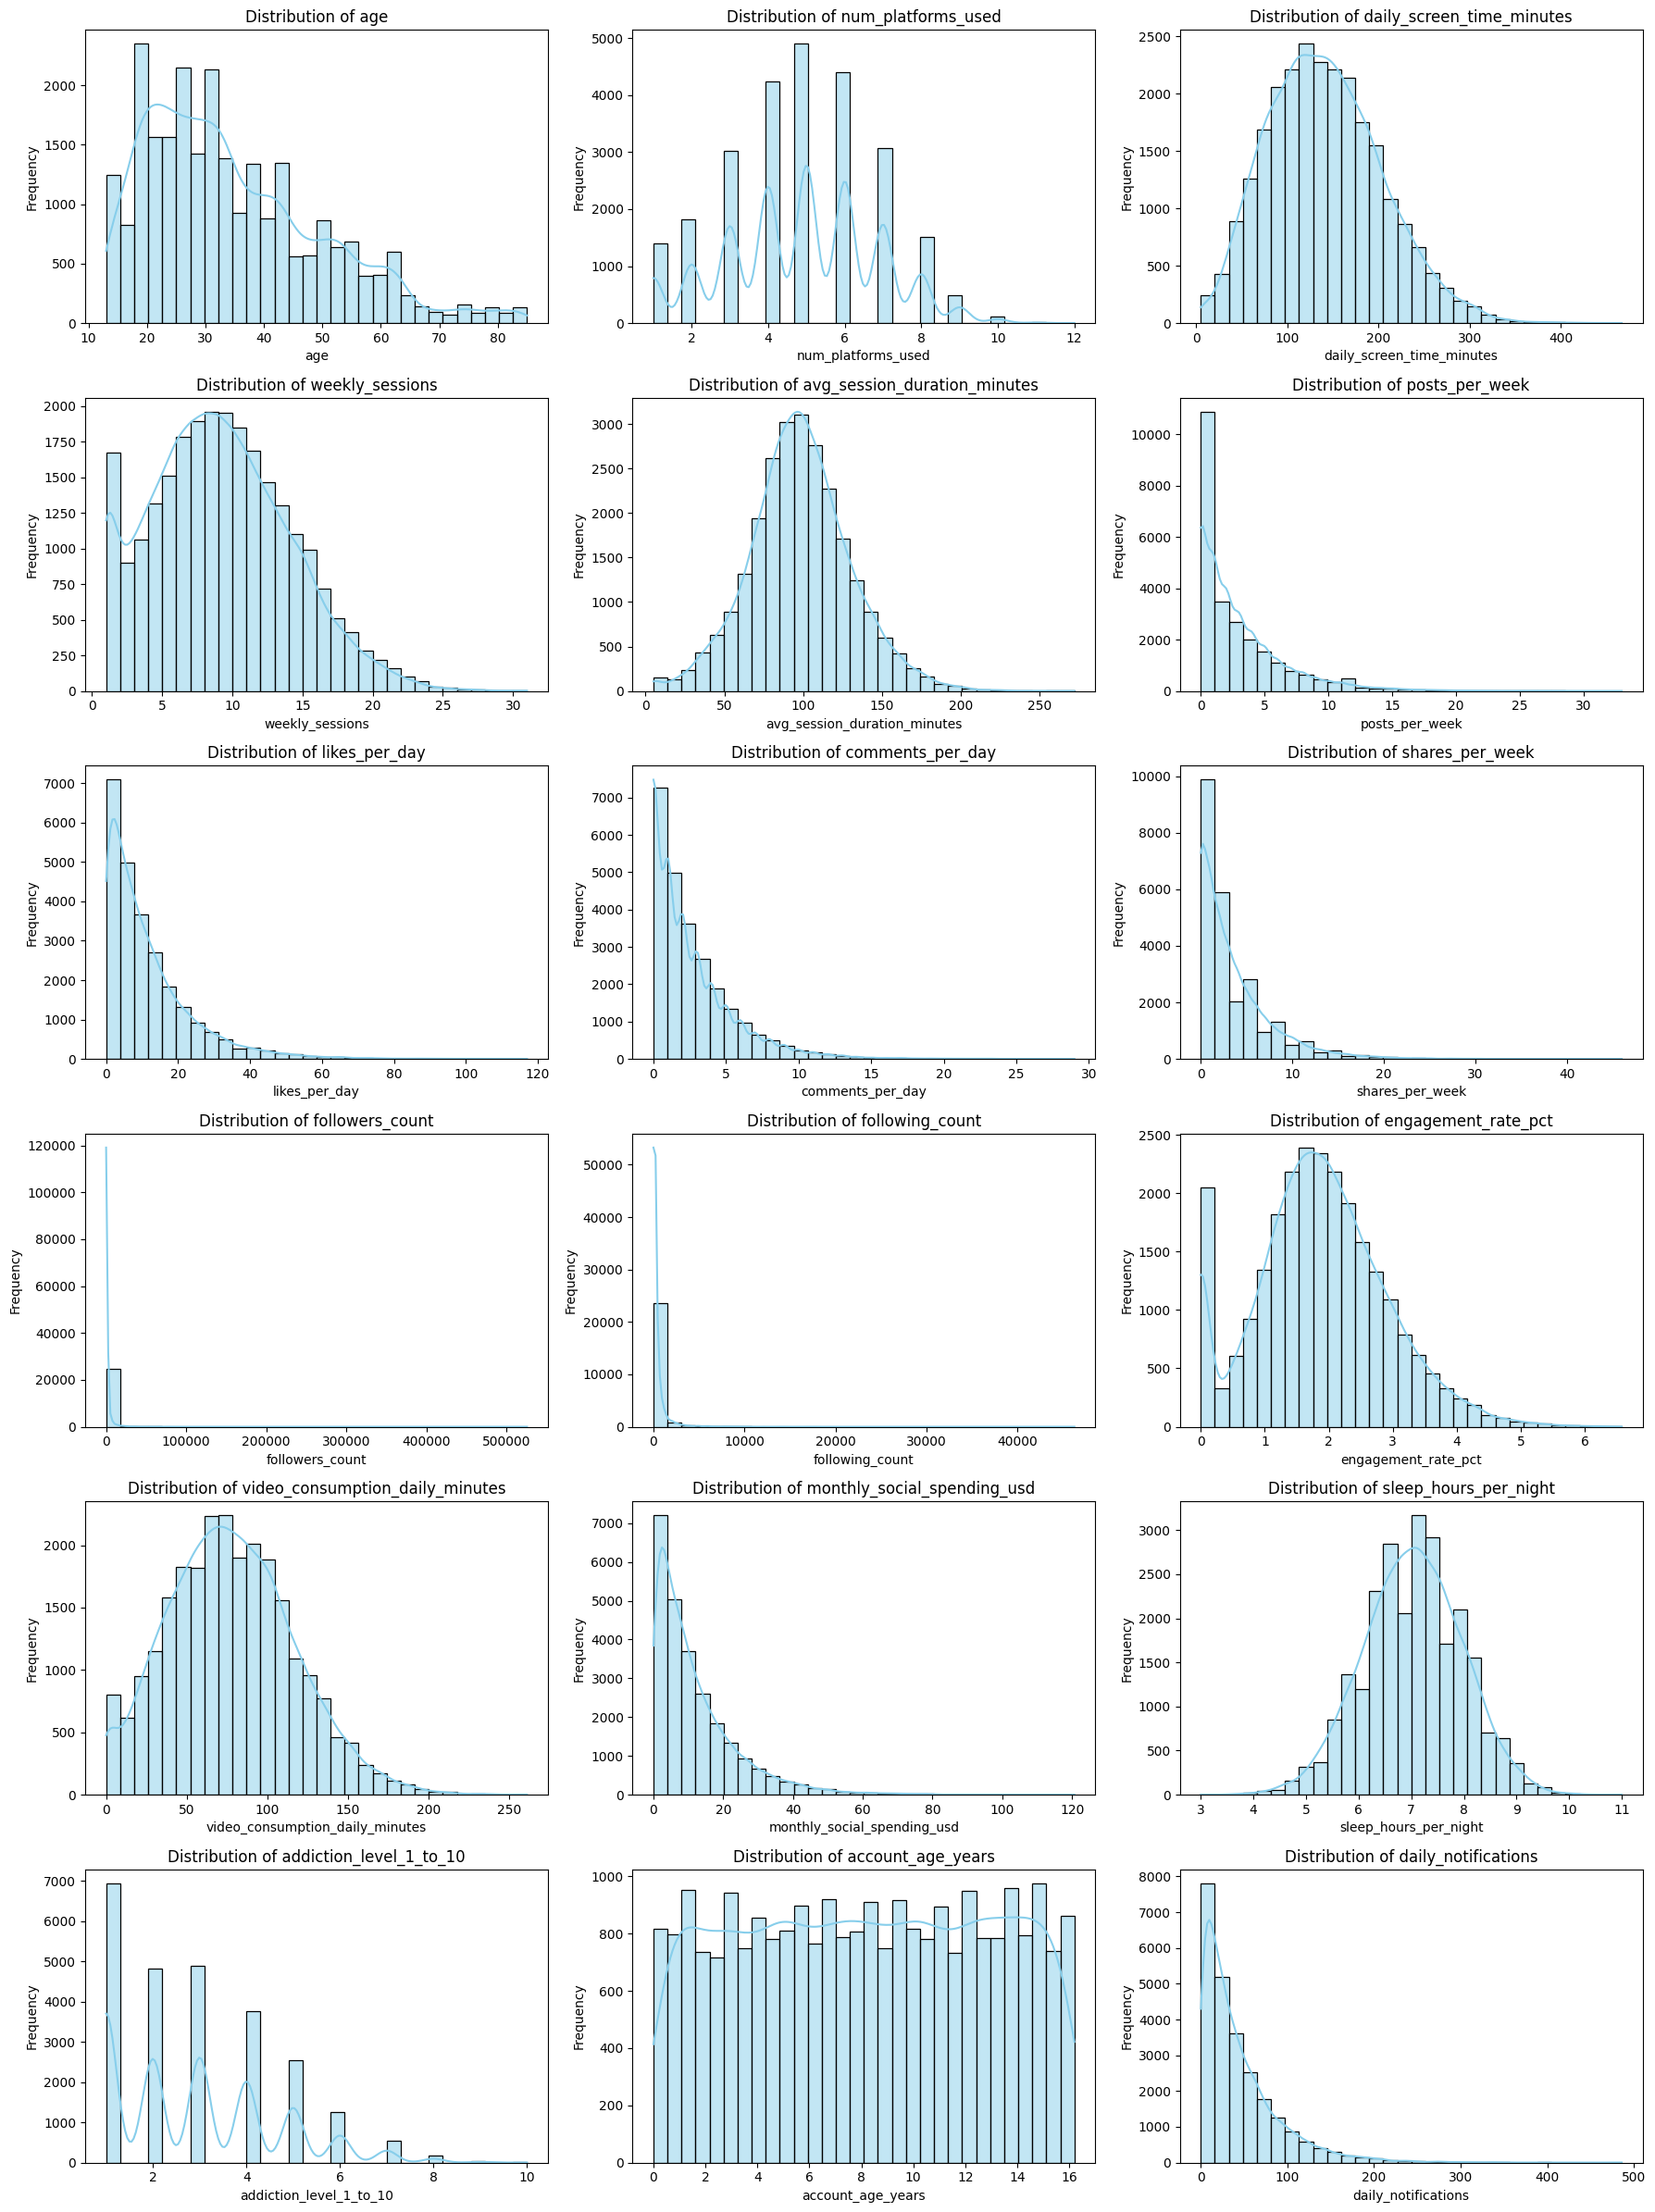

In [65]:
# Distribution of Numerical Columns
cols_per_row = 3
num_cols = len(numerical_cols)
num_rows = math.ceil(num_cols / cols_per_row)

fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(18, 4 * num_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_cols):
    sns.histplot(data[col], kde=True, bins=30, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


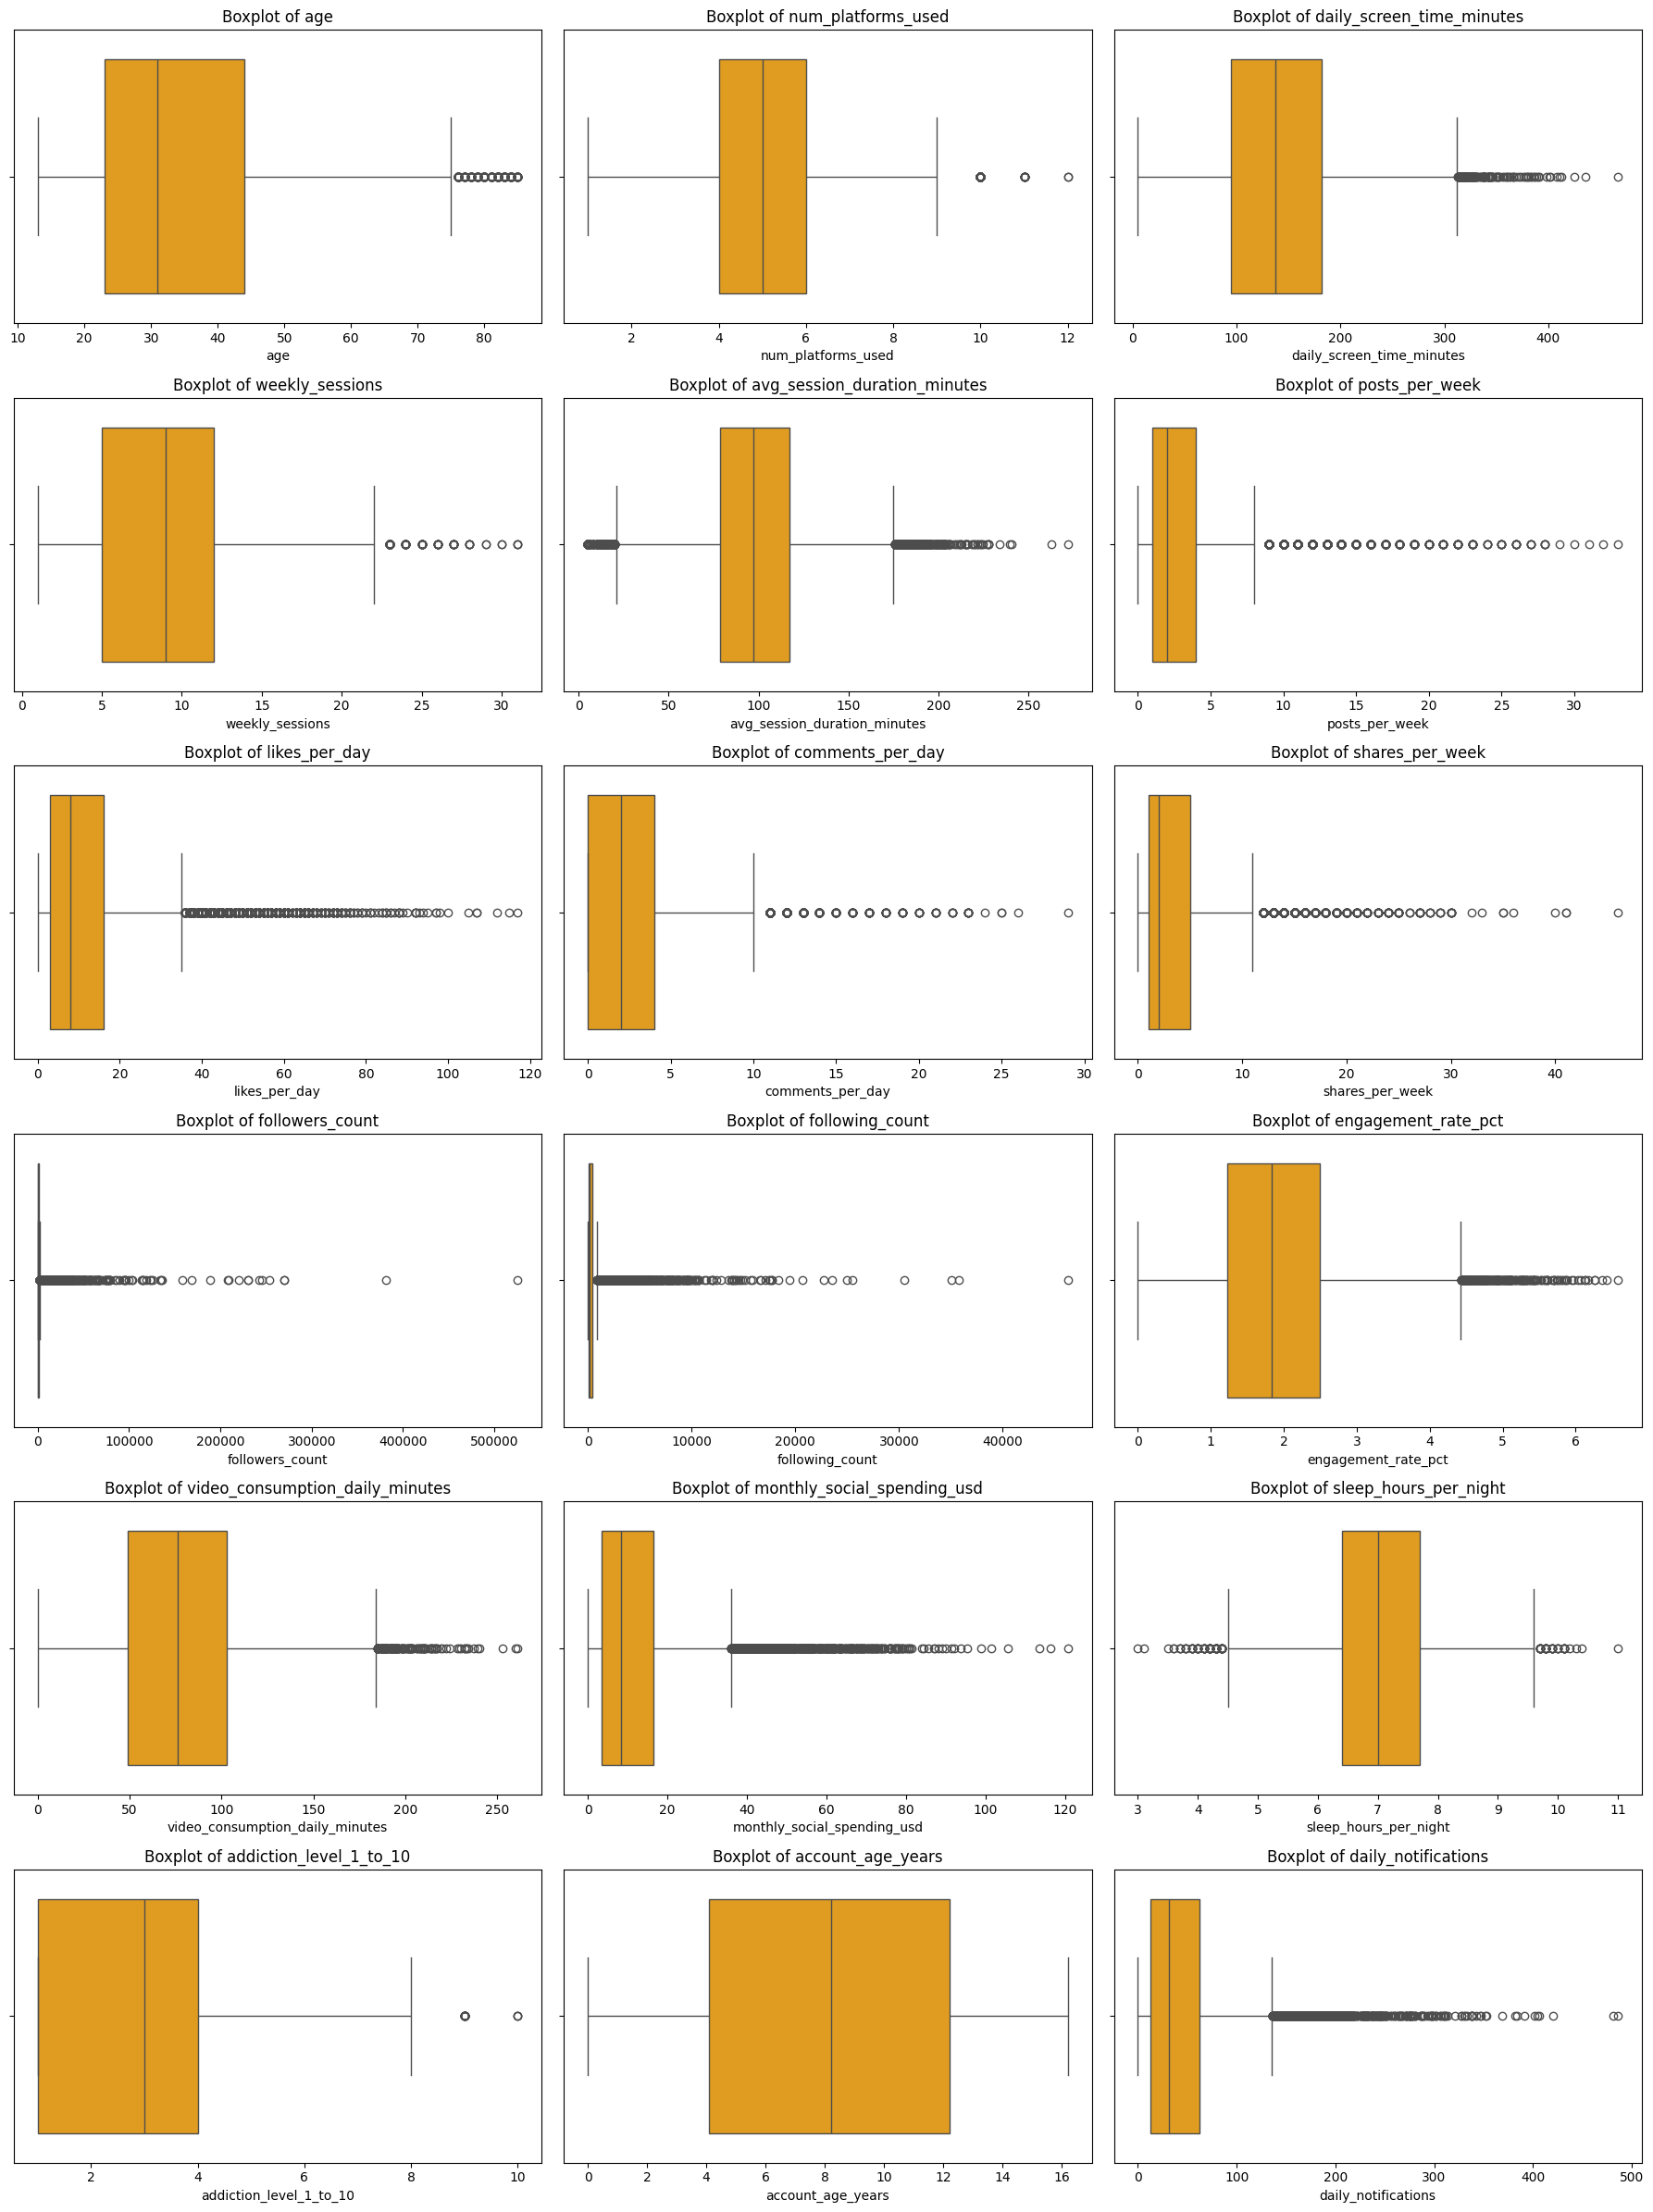

In [69]:
# Numerical Columns: Boxplots
# =========================
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(18, 4 * num_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=data[col], ax=axes[i], color="orange")
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [70]:
# remove outliers using IQR method
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data = data[(data[col] >= lower_bound) & (data[col] <= upper_bound)]


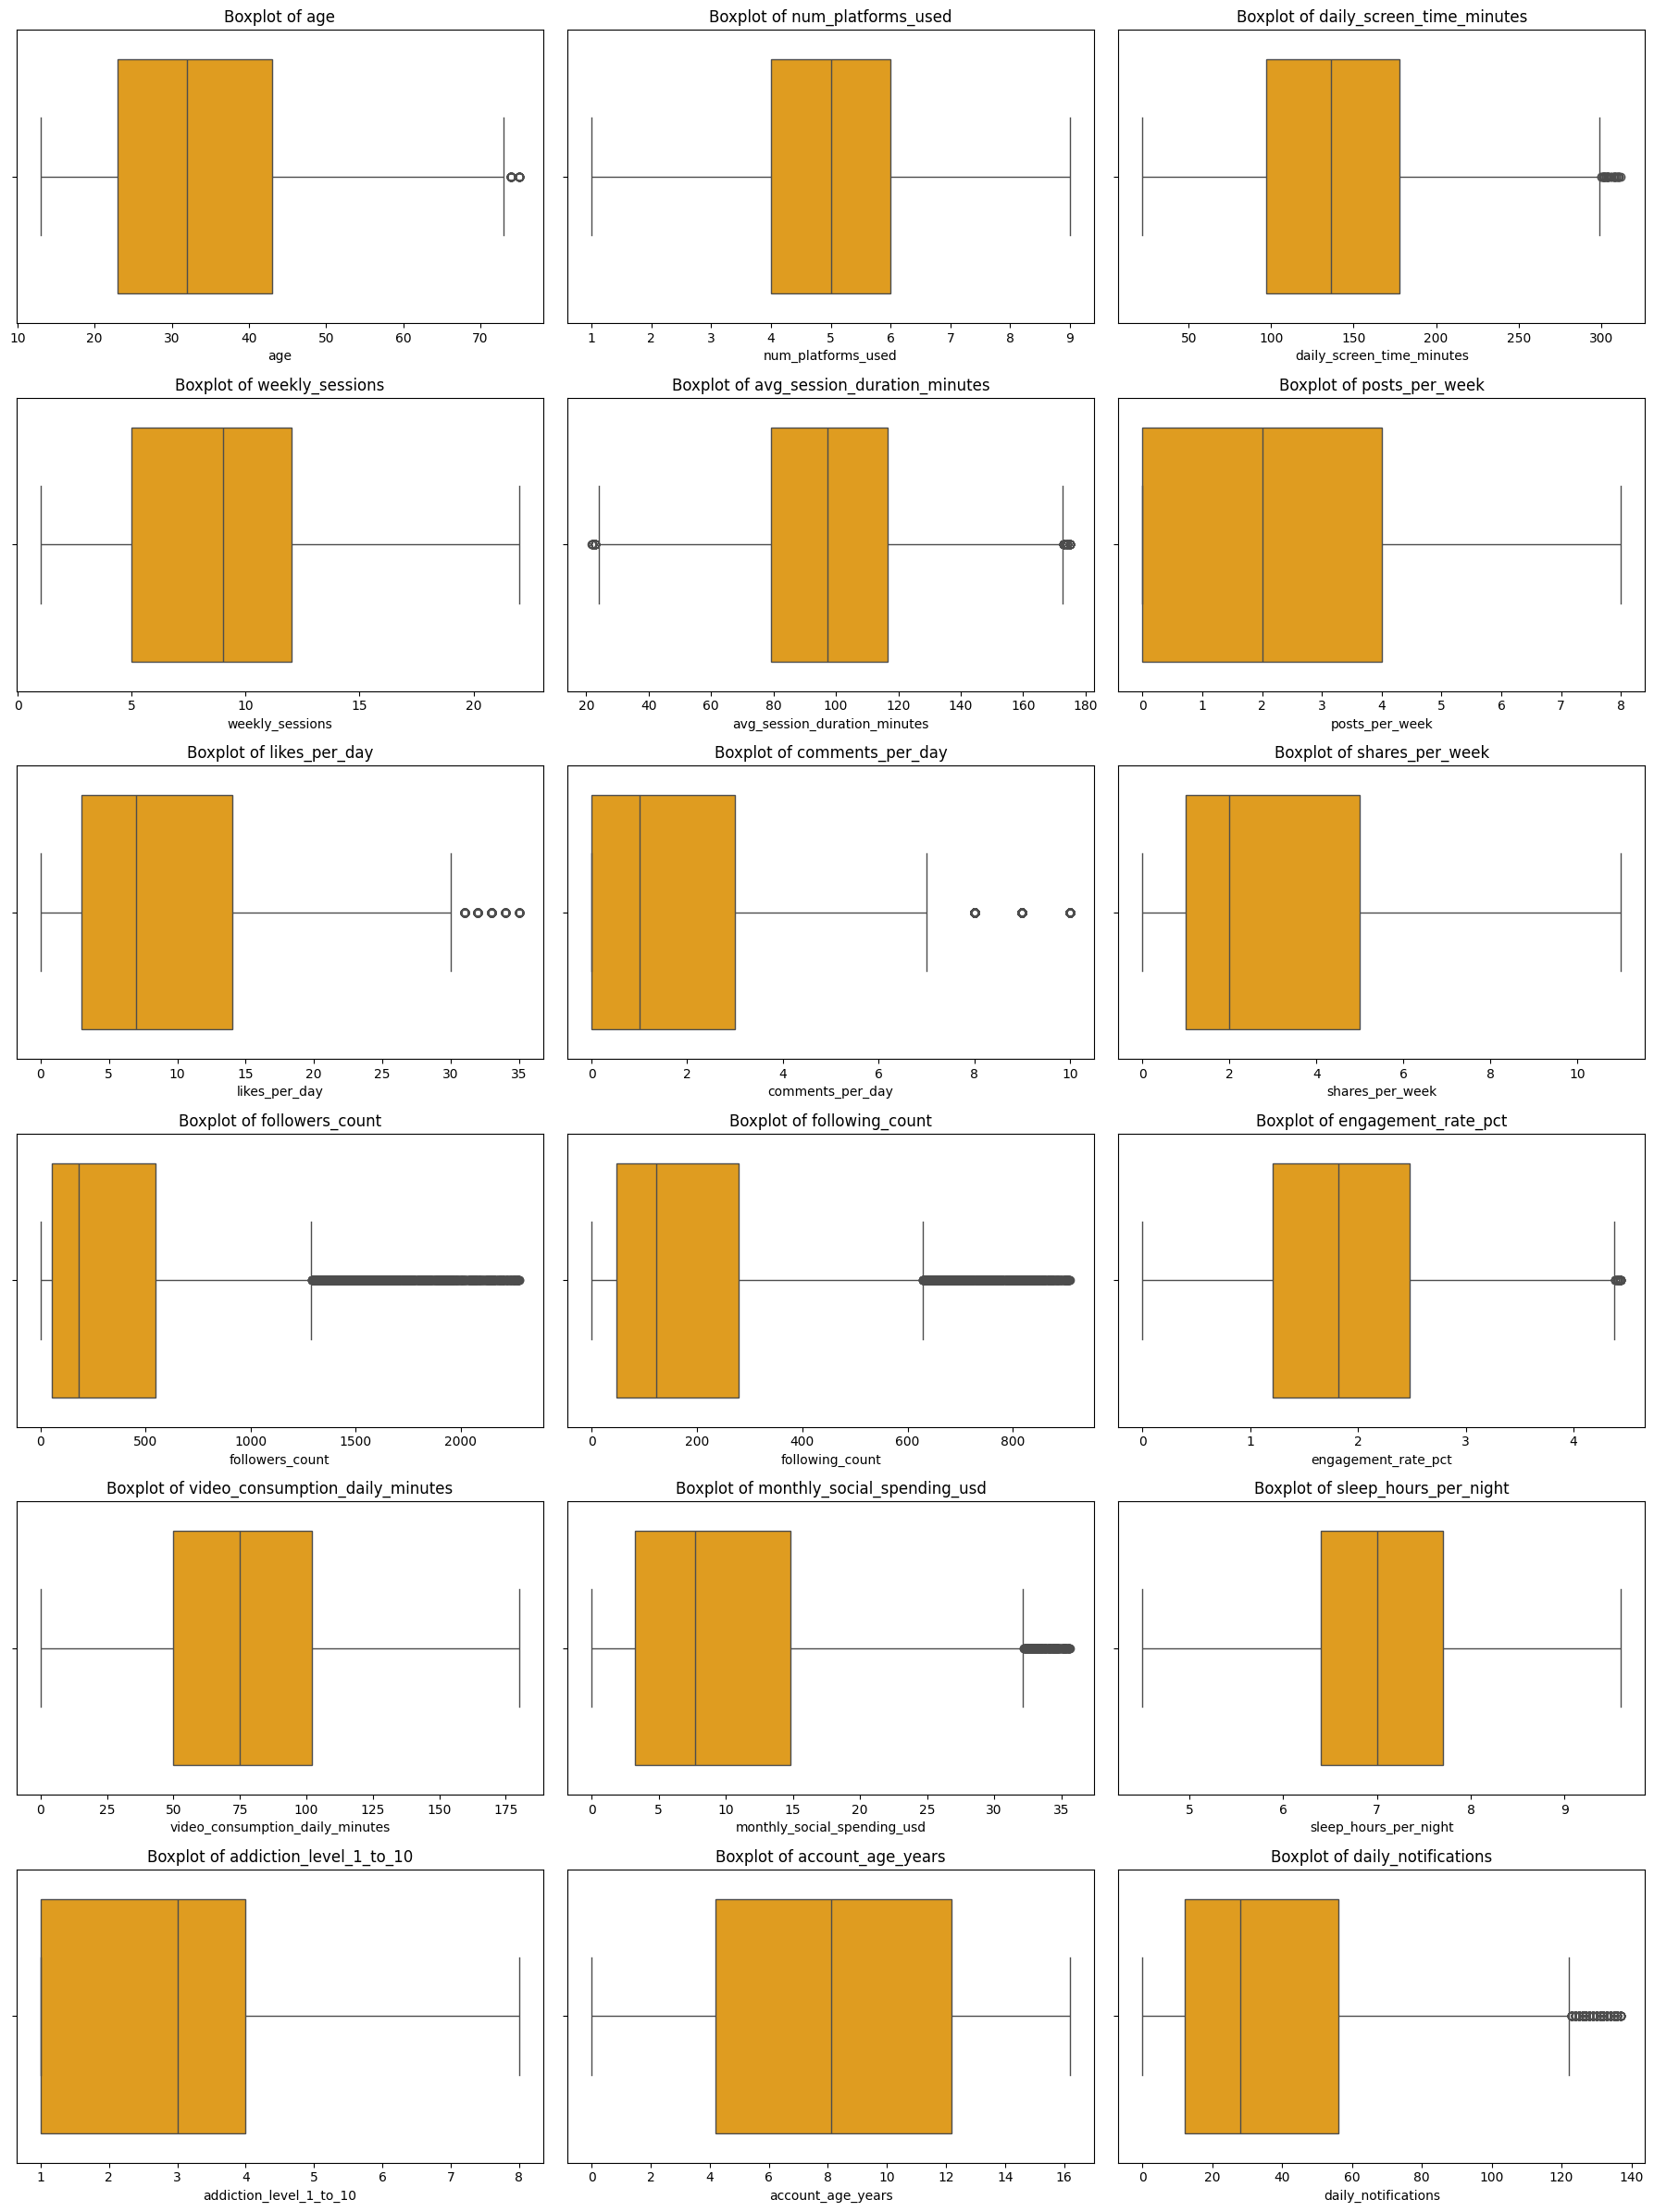

In [71]:
# Numerical Columns: Boxplots
# =========================
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(18, 4 * num_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=data[col], ax=axes[i], color="orange")
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


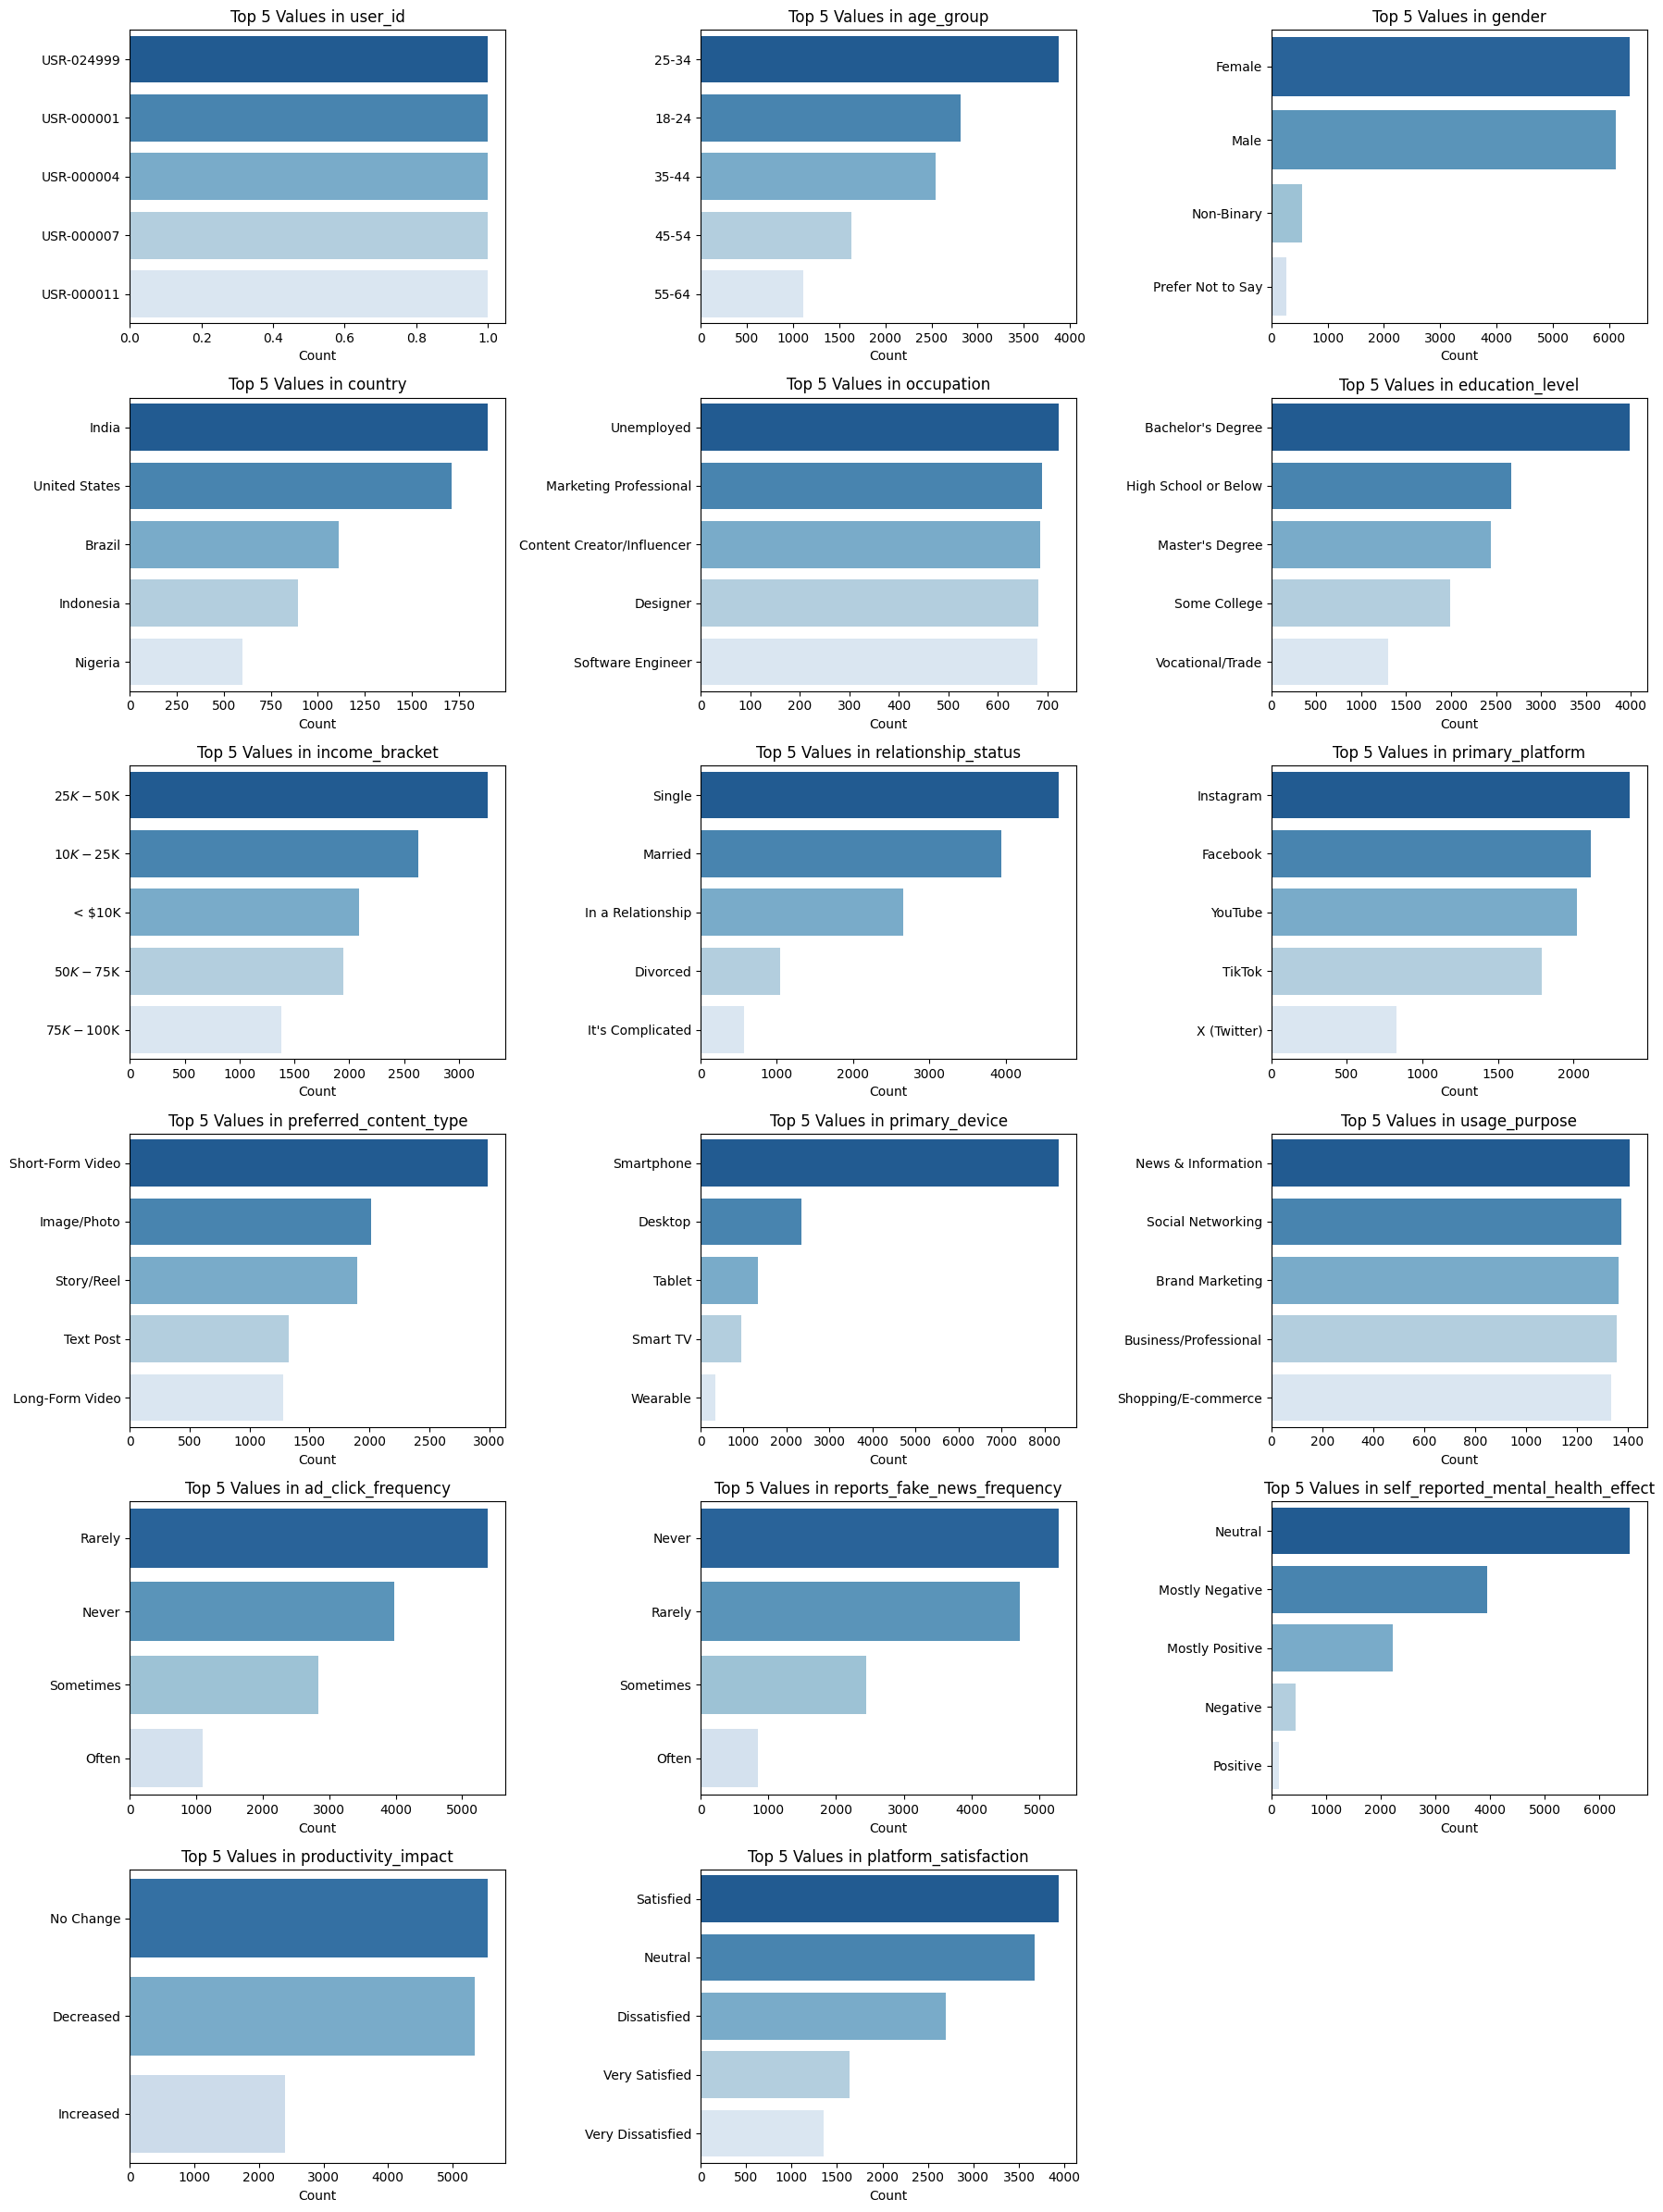

In [84]:
# Categorical Columns: Top Values
# =========================
top_n = 5
cat_cols = len(categorical_cols)
cat_rows = math.ceil(cat_cols / cols_per_row)

fig, axes = plt.subplots(cat_rows, cols_per_row, figsize=(18, 4 * cat_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    top_values = data[col].value_counts(dropna=False).head(top_n)

    sns.barplot(
        x=top_values.values,
        y=top_values.index.astype(str),
        ax=axes[i],
        palette="Blues_r"
    )

    axes[i].set_title(f"Top {top_n} Values in {col}")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



Date range for account_created_date:
Min: 2010-01-01 00:00:00
Max: 2026-03-31 00:00:00


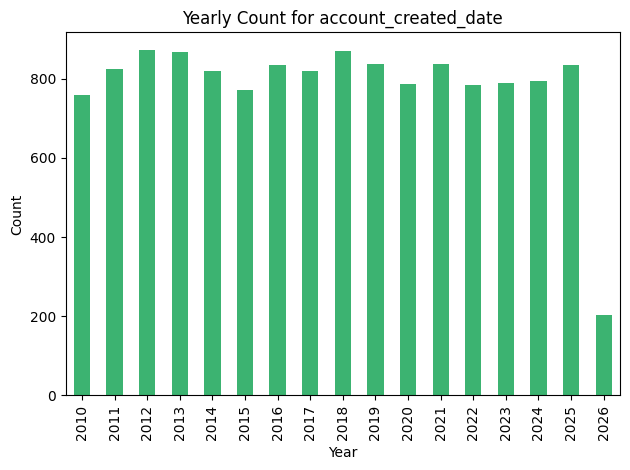

In [87]:
# Datetime Analysis
# =========================
for col in datetime_cols:
    print(f"\nDate range for {col}:")
    print("Min:", data[col].min())
    print("Max:", data[col].max())

    yearly_counts = data[col].dt.year.value_counts().sort_index()
    yearly_counts.plot(kind="bar", color="mediumseagreen")
    plt.title(f"Yearly Count for {col}")
    plt.xlabel("Year")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Social Media Dataset EDA


In [89]:
def create_grid(n_plots, cols_per_row=3, height=4):
    rows = math.ceil(n_plots / cols_per_row)
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(18, height * rows))
    axes = np.array(axes).reshape(-1)
    return fig, axes

In [88]:
# User Demographics
demographic_cols = [
    col for col in data.columns
    if any(keyword in col.lower() for keyword in ["age", "gender", "country", "location", "region", "occupation"])
]

print("\nUser Demographics Columns:")
print(demographic_cols)




User Demographics Columns:
['age', 'age_group', 'gender', 'country', 'occupation', 'usage_purpose', 'engagement_rate_pct', 'account_age_years']


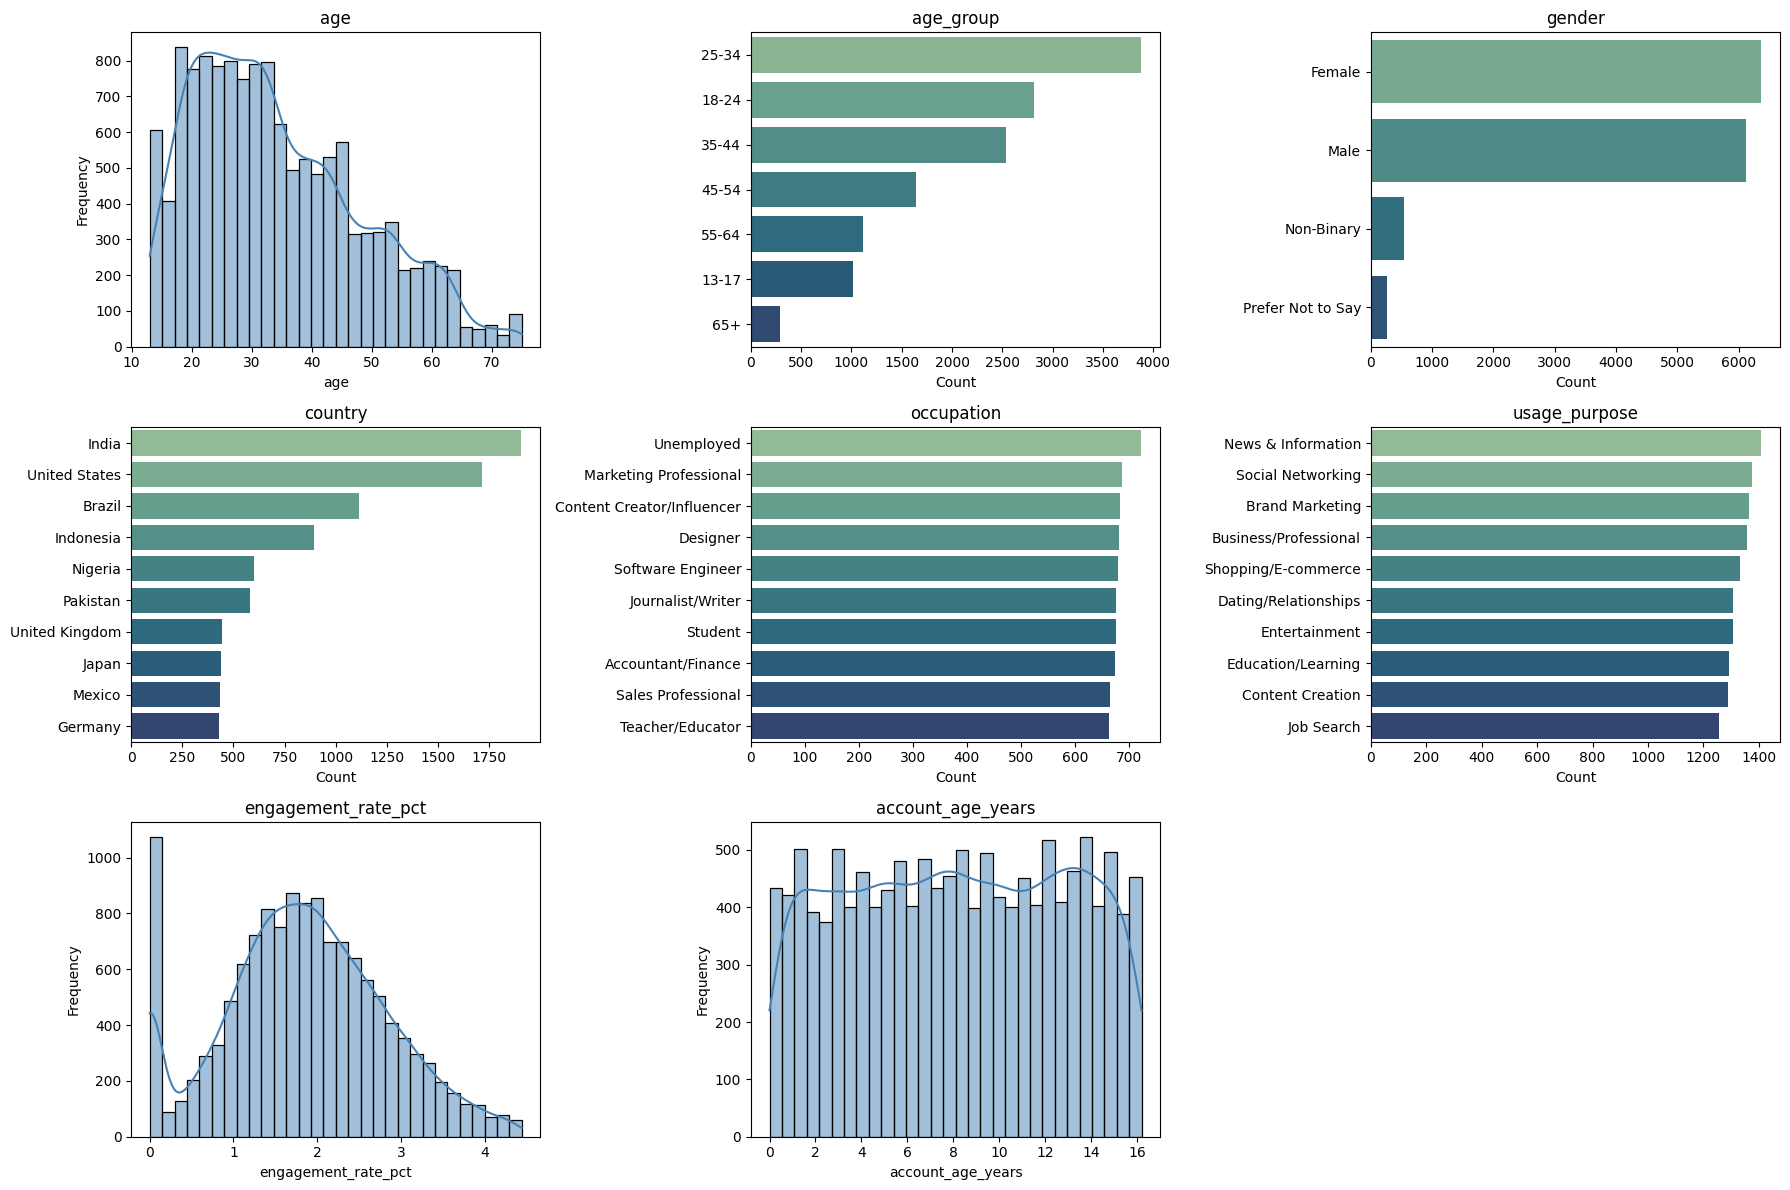

In [90]:
if demographic_cols:
    fig, axes = create_grid(len(demographic_cols), cols_per_row=3, height=4)

    for i, col in enumerate(demographic_cols):
        if data[col].dtype in ["object", "category"]:
            top_values = data[col].value_counts(dropna=False).head(10)
            sns.barplot(
                x=top_values.values,
                y=top_values.index.astype(str),
                ax=axes[i],
                palette="crest"
            )
            axes[i].set_title(f"{col}")
            axes[i].set_xlabel("Count")
            axes[i].set_ylabel("")
        else:
            sns.histplot(data[col], kde=True, bins=30, ax=axes[i], color="steelblue")
            axes[i].set_title(f"{col}")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


In [91]:
# Platform Usage

platform_cols = [
    col for col in data.columns
    if any(keyword in col.lower() for keyword in ["platform", "device", "app", "usage", "session", "time_spent", "daily"])
]

print("\nPlatform Usage Columns:")
print(platform_cols)




Platform Usage Columns:
['primary_platform', 'num_platforms_used', 'daily_screen_time_minutes', 'weekly_sessions', 'avg_session_duration_minutes', 'primary_device', 'usage_purpose', 'video_consumption_daily_minutes', 'platform_satisfaction', 'daily_notifications']


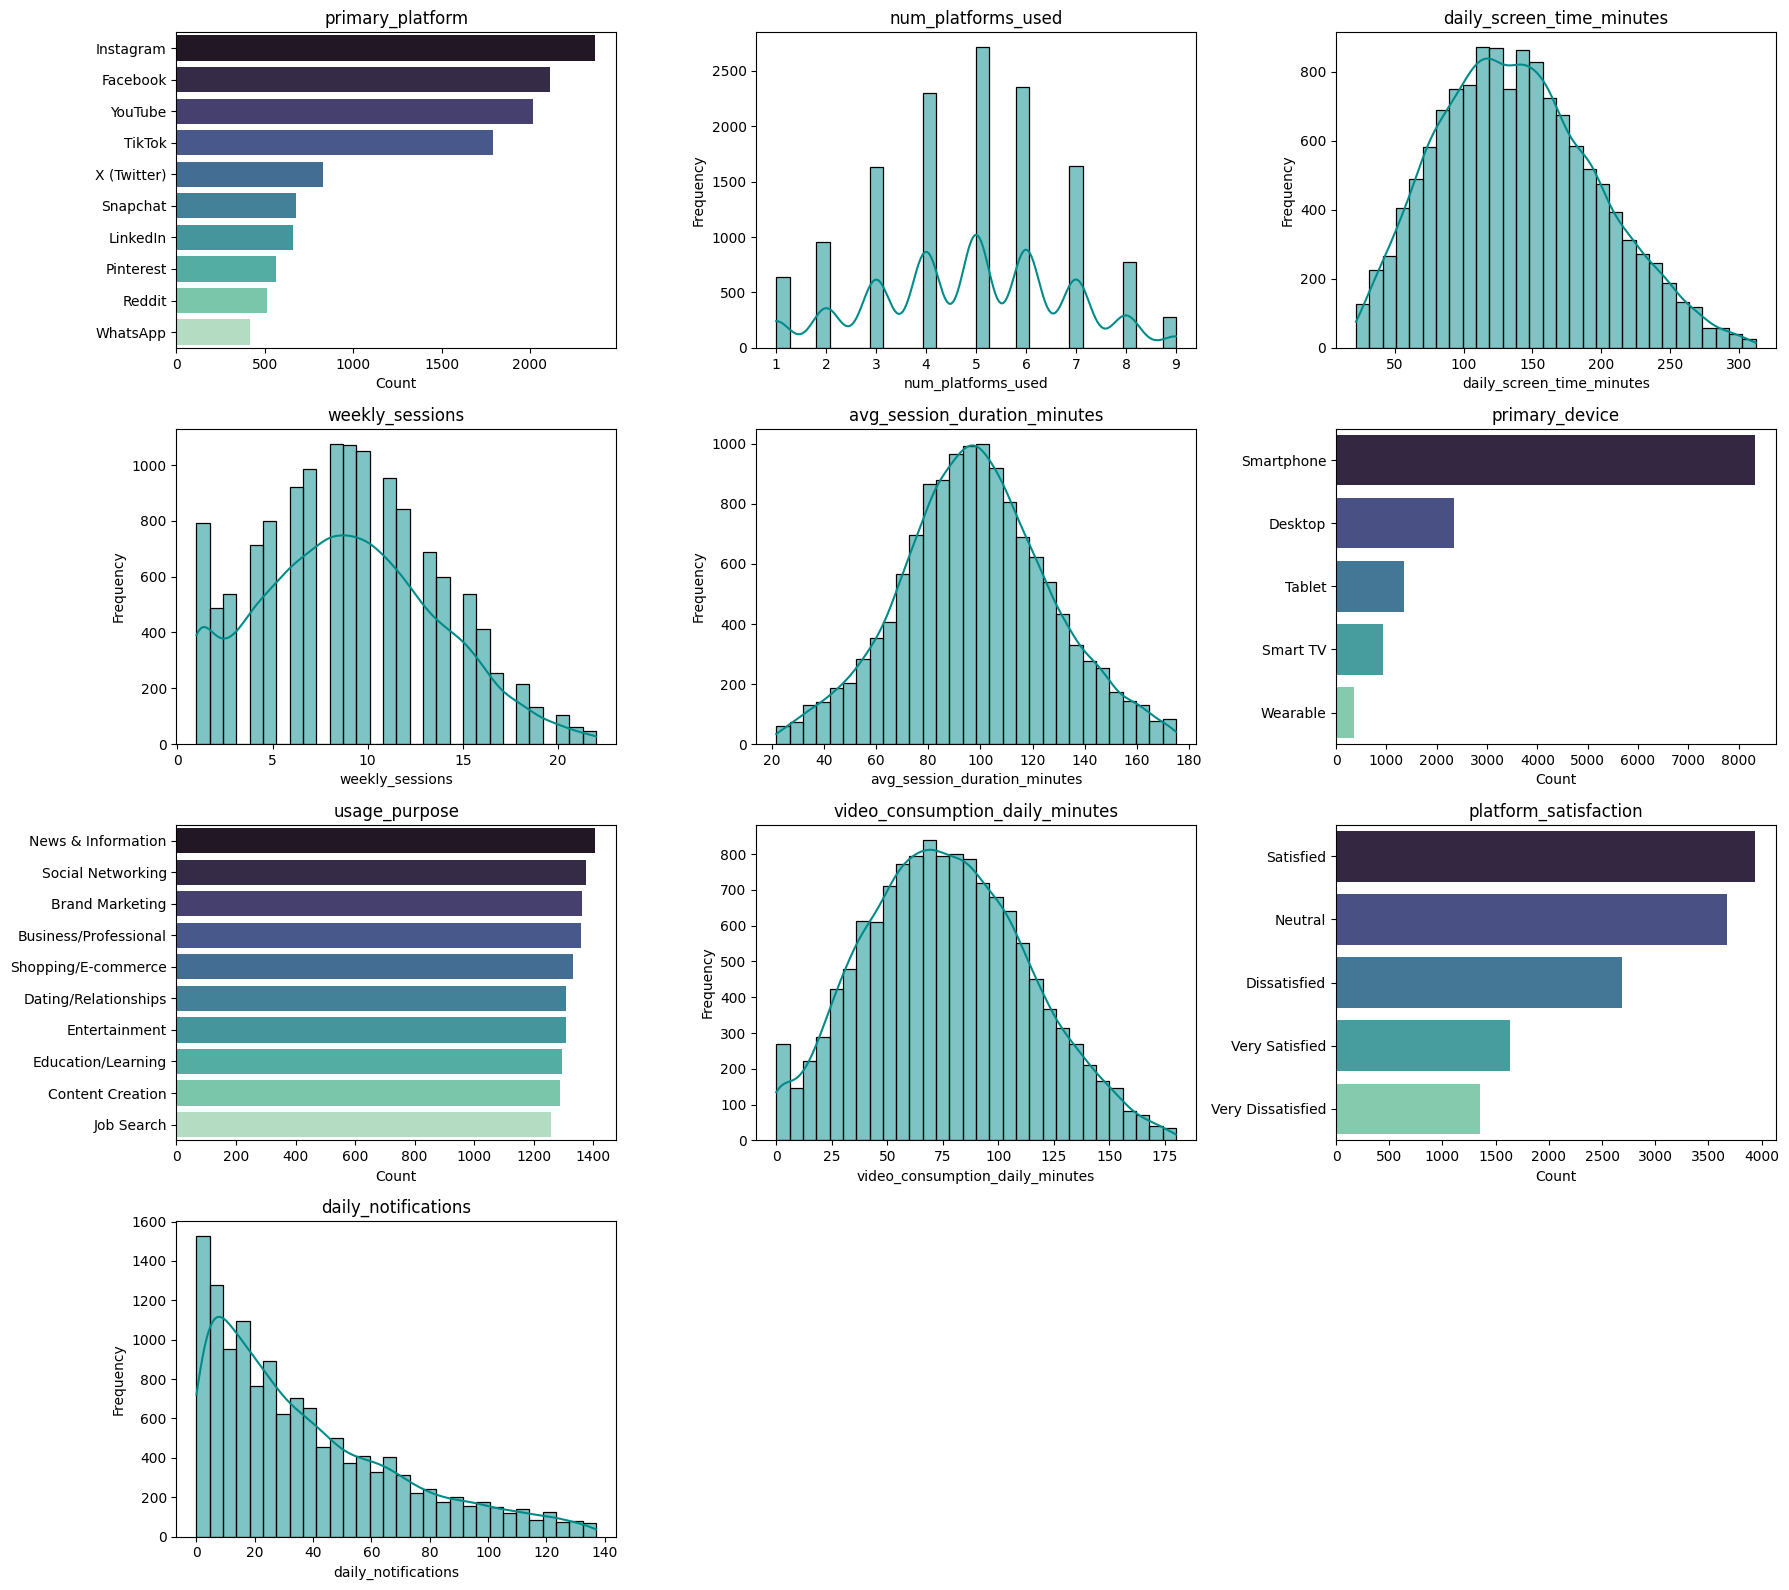

In [92]:
if platform_cols:
    fig, axes = create_grid(len(platform_cols), cols_per_row=3, height=4)

    for i, col in enumerate(platform_cols):
        if data[col].dtype in ["object", "category"]:
            top_values = data[col].value_counts(dropna=False).head(10)
            sns.barplot(
                x=top_values.values,
                y=top_values.index.astype(str),
                ax=axes[i],
                palette="mako"
            )
            axes[i].set_title(f"{col}")
            axes[i].set_xlabel("Count")
            axes[i].set_ylabel("")
        else:
            sns.histplot(data[col], kde=True, bins=30, ax=axes[i], color="darkcyan")
            axes[i].set_title(f"{col}")
            axes[i].set_xlabel(col)
            axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()



In [93]:
# Engagement Analysis
engagement_cols = [
    col for col in data.columns
    if any(keyword in col.lower() for keyword in ["like", "comment", "share", "post", "engagement", "follower", "following", "view", "click"])
]

print("\nEngagement Columns:")
print(engagement_cols)




Engagement Columns:
['posts_per_week', 'likes_per_day', 'comments_per_day', 'shares_per_week', 'followers_count', 'following_count', 'engagement_rate_pct', 'ad_click_frequency']


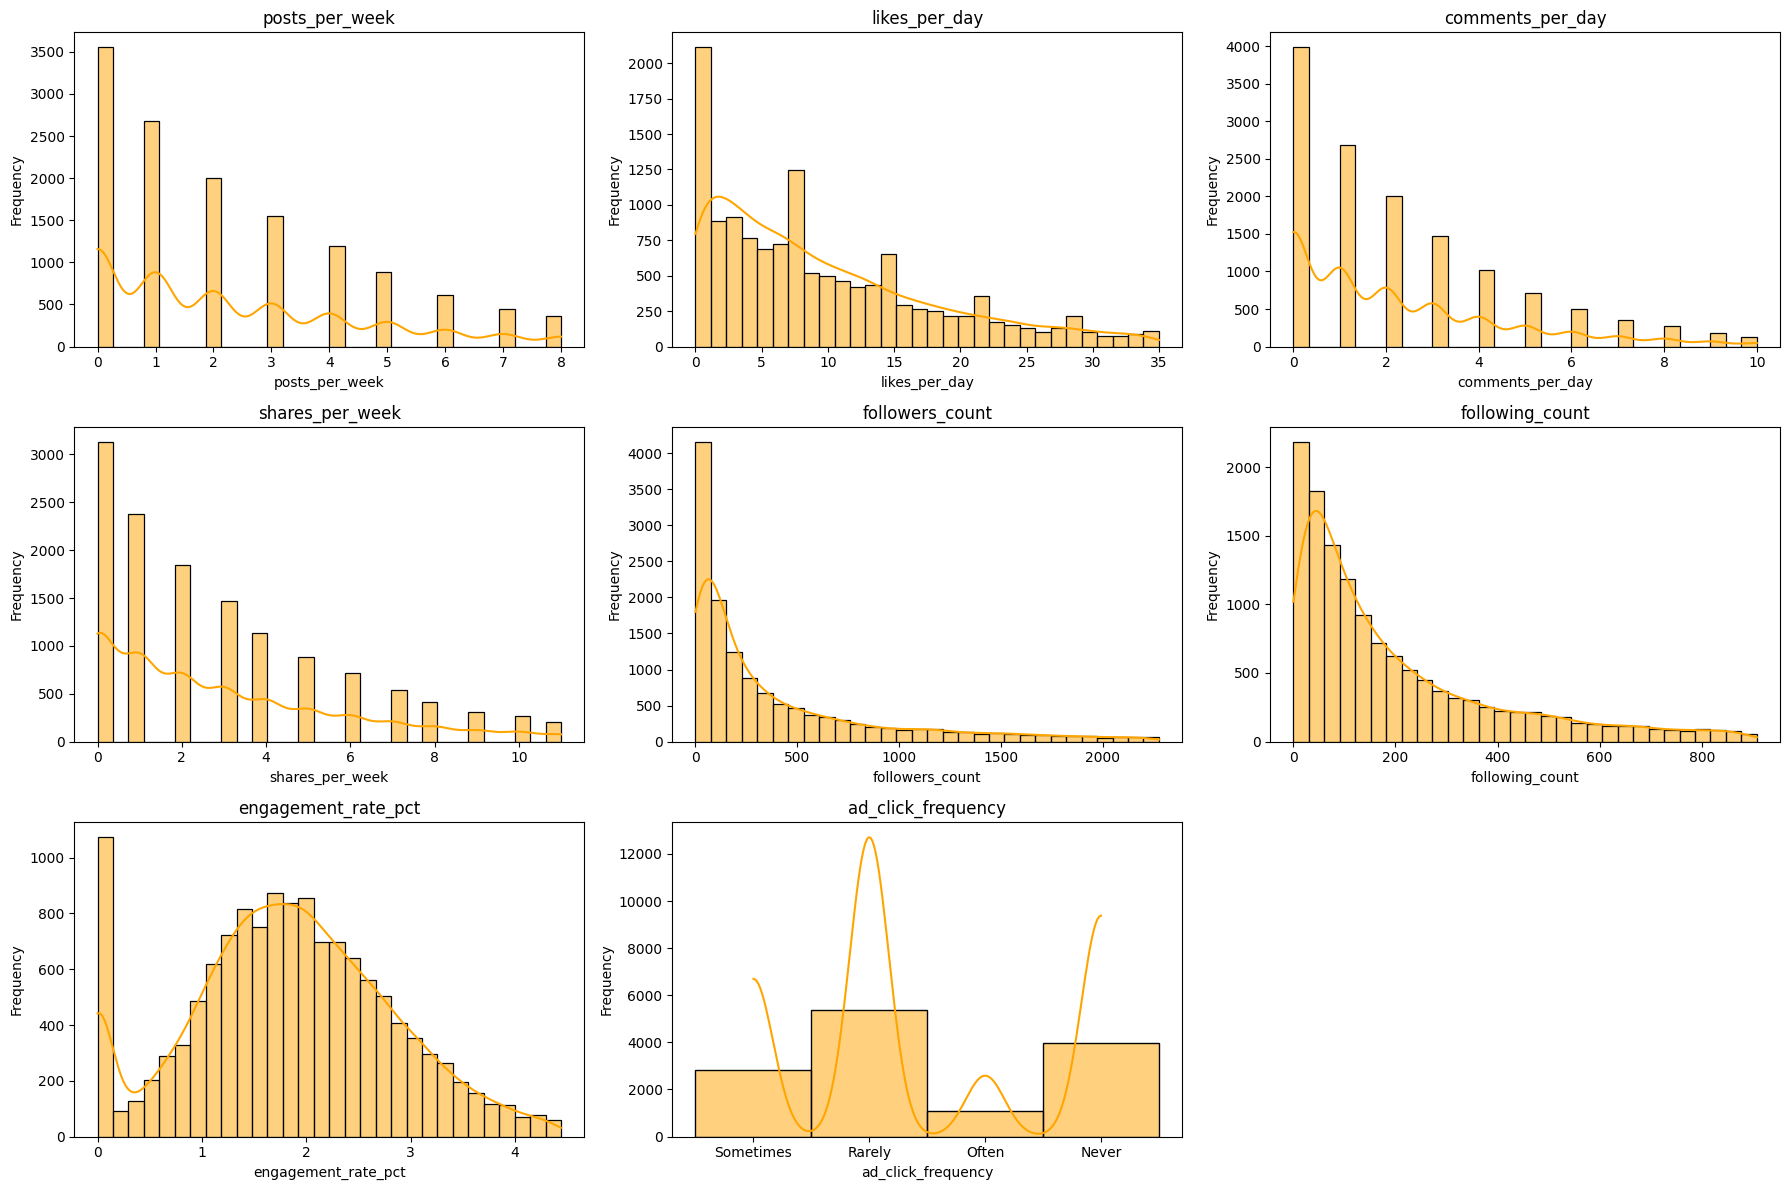

In [98]:
if engagement_cols:
    fig, axes = create_grid(len(engagement_cols), cols_per_row=3, height=4)

    for i, col in enumerate(engagement_cols):
        sns.histplot(data[col], kde=True, bins=30, ax=axes[i], color="orange")
        axes[i].set_title(f"{col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


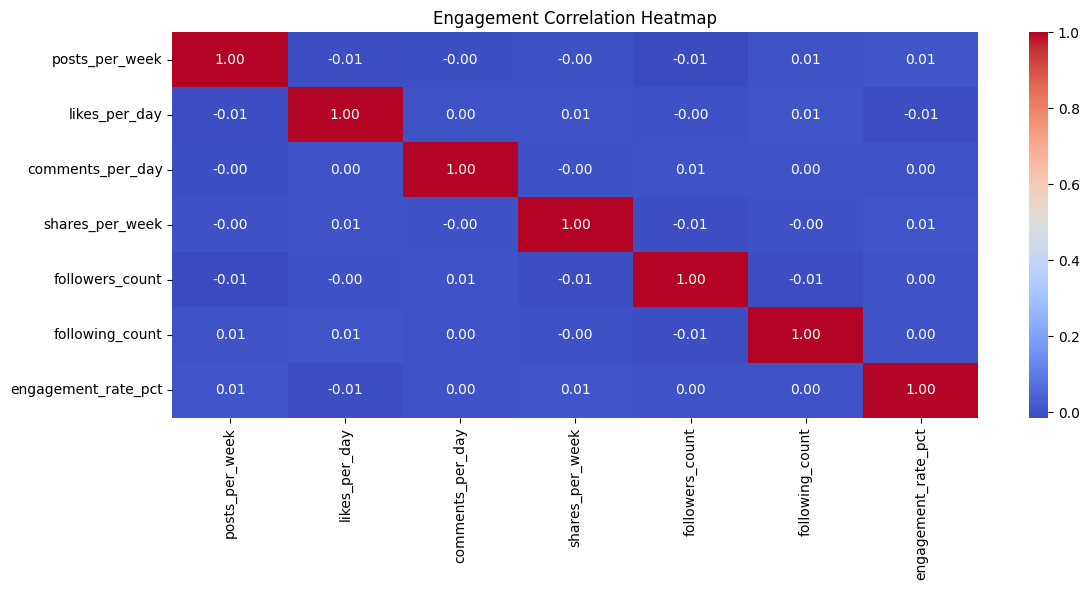

In [97]:
if len(engagement_cols) > 1:
    plt.figure(figsize=(12, 6))
    corr = data[engagement_cols].corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Engagement Correlation Heatmap")
    plt.tight_layout()
    plt.show()


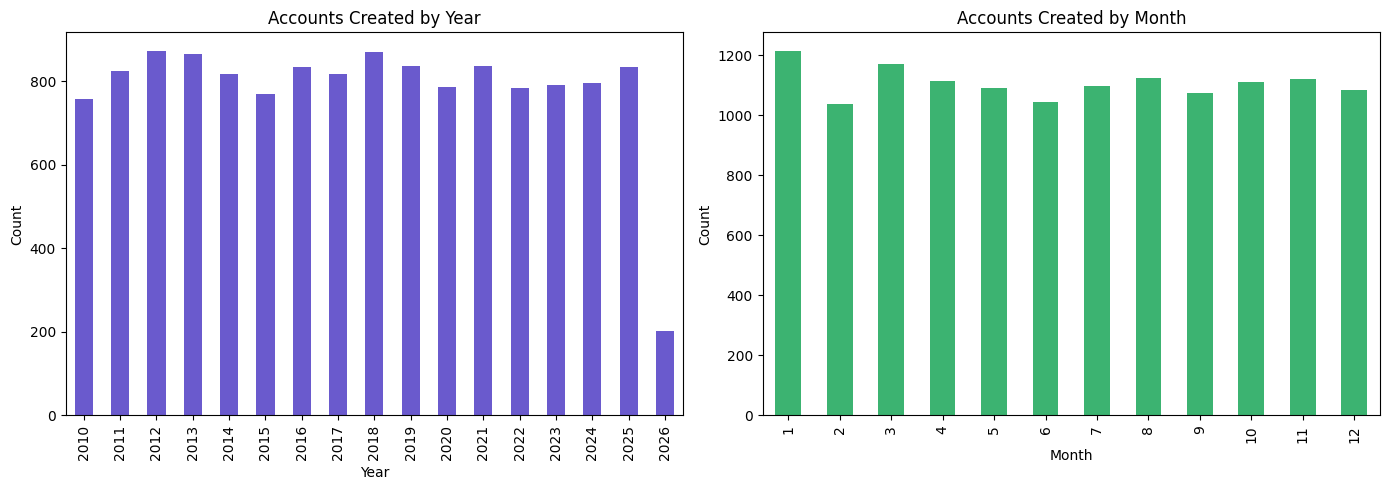

In [99]:
# Time and Date Trends

if "account_created_date" in data.columns:
    if pd.api.types.is_datetime64_any_dtype(data["account_created_date"]):
        data["account_created_year"] = data["account_created_date"].dt.year
        data["account_created_month"] = data["account_created_date"].dt.month

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        data["account_created_year"].value_counts().sort_index().plot(
            kind="bar", ax=axes[0], color="slateblue"
        )
        axes[0].set_title("Accounts Created by Year")
        axes[0].set_xlabel("Year")
        axes[0].set_ylabel("Count")

        data["account_created_month"].value_counts().sort_index().plot(
            kind="bar", ax=axes[1], color="mediumseagreen"
        )
        axes[1].set_title("Accounts Created by Month")
        axes[1].set_xlabel("Month")
        axes[1].set_ylabel("Count")

        plt.tight_layout()
        plt.show()


In [ ]:
# Professional Summary Tables
categorical_summary = []

for col in demographic_cols + platform_cols + engagement_cols:
    if data[col].dtype in ["object", "category"]:
        top_values = data[col].value_counts(dropna=False).head(5)
        summary = {
            "column": col,
            "unique_count": data[col].nunique(),
            "most_frequent": top_values.index[0],
            "most_frequent_count": top_values.iloc[0]
        }
        categorical_summary.append(summary)


In [105]:
categorical_summary = pd.DataFrame(categorical_summary).sort_values(
    by="unique_count", ascending=False
)

print("\nCategorical summary:")
display(categorical_summary)



Categorical summary:


,column,unique_count,most_frequent,most_frequent_count
2,country,35,India,1904
3,occupation,20,Unemployed,722
5,primary_platform,15,Instagram,2369
4,usage_purpose,10,News & Information,1406
7,usage_purpose,10,News & Information,1406
0,age_group,7,25-34,3876
8,platform_satisfaction,5,Satisfied,3936
6,primary_device,5,Smartphone,8322
1,gender,4,Female,6359
9,ad_click_frequency,4,Rarely,5385


In [106]:
numeric_summary = data[demographic_cols + platform_cols + engagement_cols].describe().T
print("\nNumeric summary:")
display(numeric_summary)


Numeric summary:


,count,mean,std,min,25%,50%,75%,max
age,13289.0,34.352622,13.945925,13.0,23.00,32.00,43.00,75.00
engagement_rate_pct,13289.0,1.831485,0.979950,0.0,1.21,1.82,2.48,4.44
account_age_years,13289.0,8.148717,4.668410,0.0,4.20,8.10,12.20,16.20
num_platforms_used,13289.0,4.855369,1.894175,1.0,4.00,5.00,6.00,9.00
daily_screen_time_minutes,13289.0,139.692001,57.474319,22.0,97.00,136.00,178.00,312.00
weekly_sessions,13289.0,8.966514,4.688603,1.0,5.00,9.00,12.00,22.00
avg_session_duration_minutes,13289.0,98.091452,28.906685,21.7,79.30,97.40,116.70,175.00
video_consumption_daily_minutes,13289.0,76.422530,36.531703,0.0,50.00,75.00,102.00,180.00
daily_notifications,13289.0,37.663255,32.487867,0.0,12.00,28.00,56.00,137.00
posts_per_week,13289.0,2.276018,2.196913,0.0,0.00,2.00,4.00,8.00
